In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/clean_customer_support_dataset_with_derived_sentiment.csv")

print(df.shape)

df.head()

(100000, 25)


,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,customer_sentiment,csat_score,has_attachment,platform,region,message_length,word_count,is_resolved,predicted_emotion,customer_sentiment_derived
0,TCKT_000001,2024-01-31 05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,...,very_negative,1,0,android,EU,58,11,1,neutral,neutral
1,TCKT_000002,2024-10-20 06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,...,neutral,3,0,web,Unknown,43,8,1,surprise,neutral
2,TCKT_000003,2024-06-18 21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,...,neutral,3,0,android,MEA,53,9,0,anger,very_negative
3,TCKT_000004,2025-12-25 15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,...,positive,5,1,android,LATAM,58,11,0,neutral,neutral
4,TCKT_000005,2023-08-27 16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,...,very_negative,2,0,web,Unknown,63,11,1,neutral,neutral


In [4]:
columns = [

    "issue_type",

    "priority",

    "channel",

    "customer_segment",

    "platform",

    "region",

    "product_area",

    "customer_sentiment_derived",

    "has_attachment",

    "resolution_time_hours"

]

df = df[columns]

df = df.dropna()

df.head()

,issue_type,priority,channel,customer_segment,platform,region,product_area,customer_sentiment_derived,has_attachment,resolution_time_hours
0,account_access,low,email,individual,android,EU,data_export,neutral,0,36.53
1,security_concern,medium,in_app,individual,web,Unknown,billing,neutral,0,238.32
4,billing_problem,low,phone_transcript,enterprise,web,Unknown,login_auth,neutral,0,61.32
5,performance,low,email,education,ios,Unknown,mobile_app,neutral,0,226.93
6,security_concern,urgent,in_app,education,api_client,APAC,billing,neutral,1,4.36


In [6]:
def escalation_score(row):

    score = 0

    priority_scores = {
        "low": 1,
        "medium": 2,
        "high": 4,
        "urgent": 6
    }

    score += priority_scores.get(str(row["priority"]).lower(), 2)

    sentiment_scores = {
        "positive": 0,
        "neutral": 1,
        "negative": 3,
        "very_negative": 5
    }

    score += sentiment_scores.get(str(row["customer_sentiment_derived"]).lower(), 1)

    critical_products = ["security", "login_auth", "api_integration", "payments", "billing"]
    if any(p in str(row["product_area"]).lower() for p in critical_products):
        score += 2

    critical_issues = ["security_concern", "bug", "billing_problem"]
    if row["issue_type"] in critical_issues:
        score += 2

    if str(row["customer_segment"]).lower() == "enterprise":
        score += 2

    if row["has_attachment"] == 1:
        score += 1

    if row["resolution_time_hours"] > 72:
        score += 3
    elif row["resolution_time_hours"] > 24:
        score += 1

    return score

In [7]:
df["risk_score"] = df.apply(
    escalation_score,
    axis=1
)

In [8]:
def risk_label(score):

    if score <= 5:

        return "Low"

    elif score <= 10:

        return "Medium"

    else:

        return "High"

df["escalation_risk"] = df["risk_score"].apply(
    risk_label
)

In [9]:
print(df["escalation_risk"].value_counts())

escalation_risk
Medium    32897
Low       22692
High       4524
Name: count, dtype: int64


In [10]:
df = df.drop(
    columns=[
        "risk_score",
        "resolution_time_hours"
    ]
)

In [11]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [

    "issue_type",

    "priority",

    "channel",

    "customer_segment",

    "platform",

    "region",

    "product_area",

    "customer_sentiment_derived",

    "has_attachment"

]

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    encoders[col] = le

In [12]:
target_encoder = LabelEncoder()

df["escalation_risk"] = target_encoder.fit_transform(
    df["escalation_risk"]
)

In [13]:
feature_columns = categorical_columns

X = df[feature_columns]

y = df["escalation_risk"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (48090, 9)
Testing Shape  : (12023, 9)


In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(4.429400386847195), np.int64(1): np.float64(0.883000991517021), np.int64(2): np.float64(0.609111980848881)}


In [16]:
sample_weights = y_train.map(class_weights)

In [17]:
from xgboost import XGBClassifier

model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.9,

    colsample_bytree=0.9,

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=-1

)

model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights

)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [18]:
predictions = model.predict(X_test)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, predictions))

print("Balanced Accuracy :", balanced_accuracy_score(y_test, predictions))

print("Precision :", precision_score(
    y_test,
    predictions,
    average="weighted"
))

print("Recall :", recall_score(
    y_test,
    predictions,
    average="weighted"
))

print("F1 Score :", f1_score(
    y_test,
    predictions,
    average="weighted"
))

Accuracy : 0.8447974715129335
Balanced Accuracy : 0.8392056093848742
Precision : 0.8581774048013788
Recall : 0.8447974715129335
F1 Score : 0.8487370808342757


In [20]:
print(classification_report(

    y_test,

    predictions,

    target_names=target_encoder.classes_

))

              precision    recall  f1-score   support

        High       0.54      0.81      0.65       905
         Low       0.88      0.88      0.88      4538
      Medium       0.89      0.82      0.85      6580

    accuracy                           0.84     12023
   macro avg       0.77      0.84      0.79     12023
weighted avg       0.86      0.84      0.85     12023



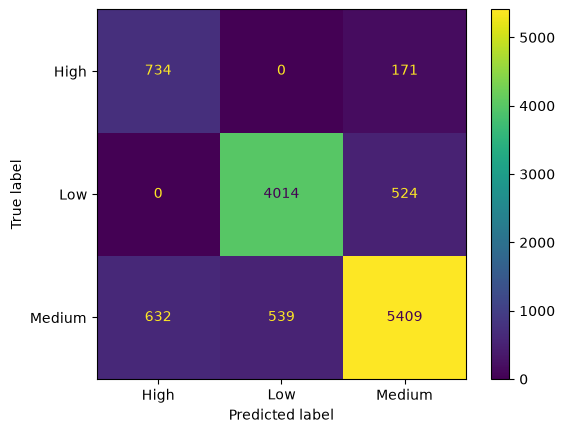

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(

    y_test,

    predictions,

    display_labels=target_encoder.classes_

)

plt.show()

                      Feature  Importance
7  customer_sentiment_derived    0.327711
1                    priority    0.180116
0                  issue_type    0.136730
3            customer_segment    0.127132
6                product_area    0.105571
8              has_attachment    0.089484
4                    platform    0.011208
2                     channel    0.011138
5                      region    0.010909


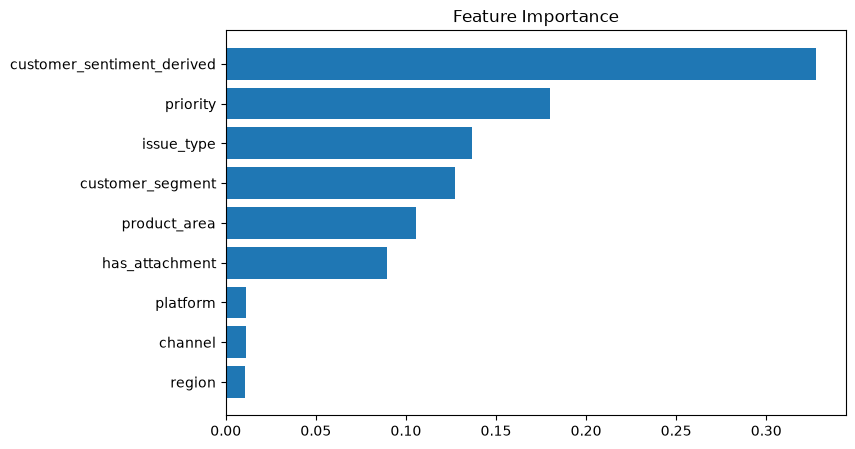

In [22]:
importance = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

print(importance)

plt.figure(figsize=(8,5))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

In [23]:
import joblib

joblib.dump(
    model,
    "../models/escalation_model.pkl"
)

joblib.dump(
    encoders,
    "../models/escalation_encoders.pkl"
)

joblib.dump(
    target_encoder,
    "../models/escalation_target_encoder.pkl"
)

['../models/escalation_target_encoder.pkl']

In [24]:
escalation_mapping = {
    "Low": {
        "color": "🟢",
        "description": "Routine issue. Standard support process is sufficient."
    },
    "Medium": {
        "color": "🟡",
        "description": "Requires closer monitoring. May need senior support involvement."
    },
    "High": {
        "color": "🔴",
        "description": "High priority. Immediate attention and possible escalation recommended."
    }
}

joblib.dump(
    escalation_mapping,
    "../models/escalation_mapping.pkl"
)

['../models/escalation_mapping.pkl']